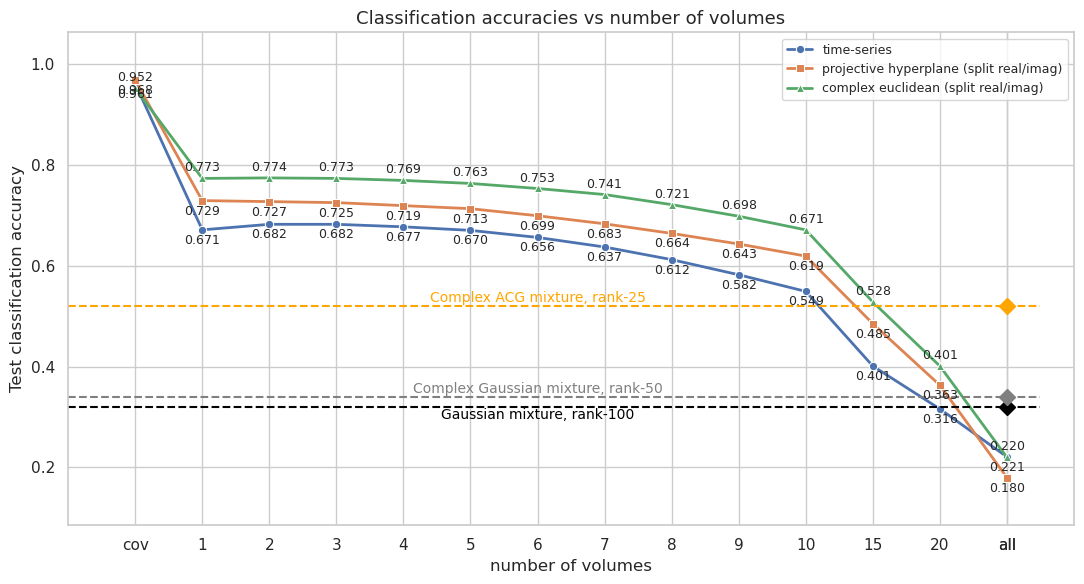

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid", context="notebook")

# x positions and labels
x_numeric = [0,1,2,3,4,5,6,7,8,9,10,11,12,13]
x_labels  = ['cov','1','2','3','4','5','6','7','8','9','10','15','20','all']
all_pos = x_numeric[-1]
x_center = np.mean(x_numeric[:-1])  # center excluding 'all'

# y-values
y_time_series = [0.961, 0.671, 0.682, 0.682, 0.677, 0.670, 0.656, 0.637, 0.612, 0.582, 0.549, 0.401, 0.316,0.221]
y_projective  = [0.968, 0.729, 0.727, 0.725, 0.719, 0.713, 0.699, 0.683, 0.664, 0.643, 0.619, 0.485, 0.363,0.180]
y_complex_euc = [0.952, 0.773, 0.774, 0.773, 0.769, 0.763, 0.753, 0.741, 0.721, 0.698, 0.671, 0.528, 0.401,0.220]

plt.figure(figsize=(11,6))

# plot lines
sns.lineplot(x=x_numeric, y=y_time_series, marker='o', label="time-series", linewidth=2)
sns.lineplot(x=x_numeric, y=y_projective,  marker='s', label="projective hyperplane (split real/imag)", linewidth=2)
sns.lineplot(x=x_numeric, y=y_complex_euc, marker='^', label="complex euclidean (split real/imag)", linewidth=2)

# annotation offsets
all_y = y_time_series + y_projective + y_complex_euc
y_min, y_max = min(all_y), max(all_y)
y_range = y_max - y_min
offset_above = 0.01 * y_range
offset_below = -0.01 * y_range

# annotate points
for x, y in zip(x_numeric, y_time_series):
    plt.text(x, y + offset_below, f"{y:.3f}", ha='center', va='top', fontsize=9)

for x, y in zip(x_numeric, y_projective):
    plt.text(x, y + offset_below, f"{y:.3f}", ha='center', va='top', fontsize=9)

for x, y in zip(x_numeric, y_complex_euc):
    plt.text(x, y + offset_above, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# horizontal reference lines (NO legend entries)
refs = [
    (0.52, 'Complex ACG mixture, rank-25', 'orange'),
    (0.32, 'Gaussian mixture, rank-100', 'black'),
    (0.34, 'Complex Gaussian mixture, rank-50', 'gray')
]

for y_ref, label_ref, color_ref in refs:
    plt.hlines(y=y_ref,
               xmin=min(x_numeric)-1,
               xmax=13+0.5,
               colors=color_ref,
               linestyles='--',
               linewidth=1.5)
    # marker above 'all'
    plt.plot(13, y_ref, marker='D', markersize=8, color=color_ref, zorder=5)
    # centered text
    if y_ref == 0.32:
        plt.text(x_center, y_ref - 0.003*y_range,
             label_ref, ha='center', va='top',
             fontsize=10, color=color_ref)
    else:
        plt.text(x_center, y_ref + 0.003*y_range,
             label_ref, ha='center', va='bottom',
             fontsize=10, color=color_ref)

# axes formatting
plt.xlabel("number of volumes", fontsize=12)
plt.ylabel("Test classification accuracy", fontsize=12)
plt.xticks(np.concatenate((x_numeric,[13])), labels=x_labels + ['all'])
plt.xlim(min(x_numeric)-1, 14)
plt.ylim(y_min - 0.12*y_range, y_max + 0.12*y_range)

plt.legend(loc='upper right', fontsize=9, frameon=True)
plt.title("Classification accuracies vs number of volumes", fontsize=13)

plt.tight_layout()
plt.show()


-----NMI-----
Stratified K-fold because different number of ecvents per subject
post-stimulus volumes, showing NMI:
time-series
'cov', 0.975
1, 0.385
2, 0.427
3, 0.440
4, 0.437
5, 0.419
6, 0.388
7, 0.345
8, 0.295
9, 0.243
10, 0.195
15, 0.05
20, 0.012

projective hyperplane (split)
'cov', 0.974
1, 0.550
2, 0.572
3, 0.573
4, 0.563
5, 0.543
6, 0.516
7, 0.483
8, 0.444
9, 0.400
10, 0.354
15, 0.132
20, 0.037

complex Euclidean (split)
'cov', 0.967
1, 
2, 
3, 
4, 0.667
5, 
6, 
7, 
8, 
9, 
10, 
15, 
20, 